# Business Case 4 — Geographic Resource Planning

## Business Objective

Understand appointment demand and no-show patterns across geographic locations to support resource planning.

The objective is to help management:

* Identify locations with higher appointment demand
* Compare no-show patterns across locations
* Support geographic allocation of specialists and equipment
* Identify locations that may require additional operational attention

> The analysis will first validate the geographic information available in the `place` field before making any assumptions about the number of cities represented in the dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_geo = pd.read_csv("../../data/Medical_appointment_data.csv")

# Remove exact duplicate rows
df_geo = df_geo.drop_duplicates().copy()

print("Dataset shape:", df_geo.shape)
print("\nNumber of unique places:", df_geo['place'].nunique())

print("\nSample place values:")
print(df_geo['place'].dropna().unique()[:30])

Dataset shape: (109557, 26)

Number of unique places: 26289

Sample place values:
<ArrowStringArray>
[  'Lake Marvinville',            'ITAPEMA',             'ITAJAÍ',
          'Sarahside',         'Stokesfort',       'Deborahmouth',
              'PENHA',          'Moranside',        'North Aaron',
         'NAVEGANTES',       'Mendozahaven', 'North Diamondburgh',
     'New Sherrifurt',          'Mooretown',        'B. CAMBORIU',
      'Elizabethfurt',      'Port Johnstad',         'Nicoleberg',
         'Greenestad',       'East Matthew',   'Port Thomasmouth',
           'Loritown',         'Mooreville',         'LUIZ ALVES',
      'North Cynthia',        'Walkermouth',           'CAMBORIU',
       'Port Timothy',          'West Jose',         'Jeanneview']
Length: 30, dtype: str


In [2]:
# Identify locations with the highest appointment volume

place_volume = (
    df_geo.groupby('place')
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show', lambda x: (x == 'yes').sum())
    )
    .reset_index()
)

place_volume['no_show_rate_pct'] = (
    place_volume['no_shows']
    / place_volume['total_appointments']
    * 100
)

place_volume = place_volume.sort_values(
    'total_appointments',
    ascending=False
)

print("Top 20 locations by appointment volume:")
print(
    place_volume.head(20)
    .round(2)
    .to_string(index=False)
)

Top 20 locations by appointment volume:
         place  total_appointments  no_shows  no_show_rate_pct
        ITAJAÍ               20512      1821              8.88
   B. CAMBORIU                6018       553              9.19
      CAMBORIU                5523       411              7.44
    NAVEGANTES                3901       410             10.51
       ITAPEMA                2665       258              9.68
     BOMBINHAS                1707       200             11.72
         PENHA                1038        64              6.17
    PORTO BELO                 950       111             11.68
BALN. PIÇARRAS                 943        63              6.68
        ILHOTA                 583        77             13.21
    LUIZ ALVES                 523        71             13.58
   New Michael                  56        24             42.86
 North Michael                  51        27             52.94
   South James                  43        28             65.12
  Lake Michael 

In [4]:
# Filter locations with sufficient appointment volume

place_analysis = place_volume[
    place_volume['total_appointments'] >= 100
].copy()

print(
    "Number of locations with at least 100 appointments:",
    len(place_analysis)
)

print("\nLocations with at least 100 appointments:")
print(
    place_analysis
    .round(2)
    .to_string(index=False)
)

Number of locations with at least 100 appointments: 11

Locations with at least 100 appointments:
         place  total_appointments  no_shows  no_show_rate_pct
        ITAJAÍ               20512      1821              8.88
   B. CAMBORIU                6018       553              9.19
      CAMBORIU                5523       411              7.44
    NAVEGANTES                3901       410             10.51
       ITAPEMA                2665       258              9.68
     BOMBINHAS                1707       200             11.72
         PENHA                1038        64              6.17
    PORTO BELO                 950       111             11.68
BALN. PIÇARRAS                 943        63              6.68
        ILHOTA                 583        77             13.21
    LUIZ ALVES                 523        71             13.58


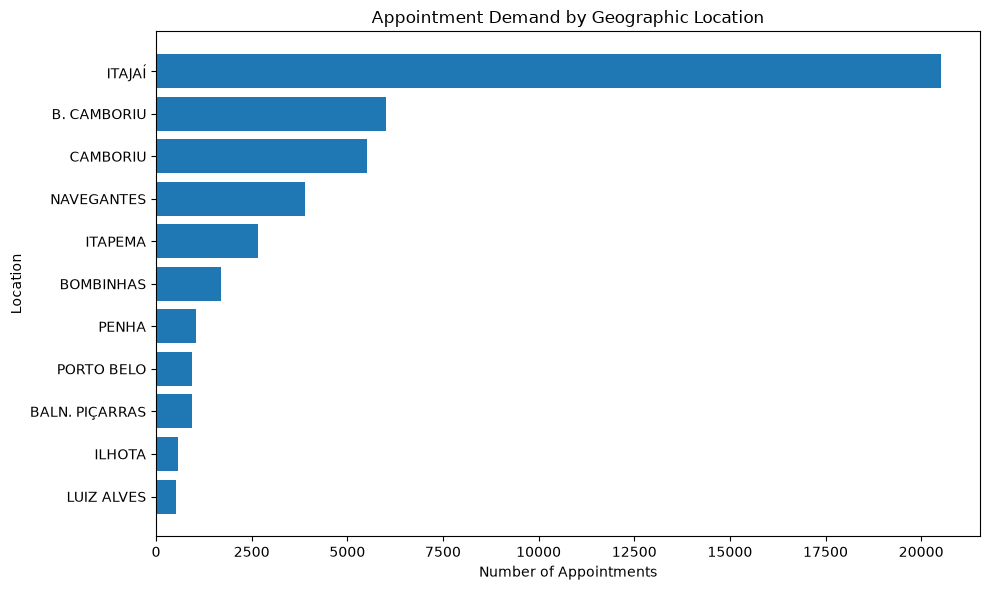

In [5]:
# Plot appointment volume by location

place_plot = place_analysis.sort_values(
    'total_appointments',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    place_plot['place'],
    place_plot['total_appointments']
)

plt.xlabel('Number of Appointments')
plt.ylabel('Location')
plt.title('Appointment Demand by Geographic Location')

plt.tight_layout()
plt.show()

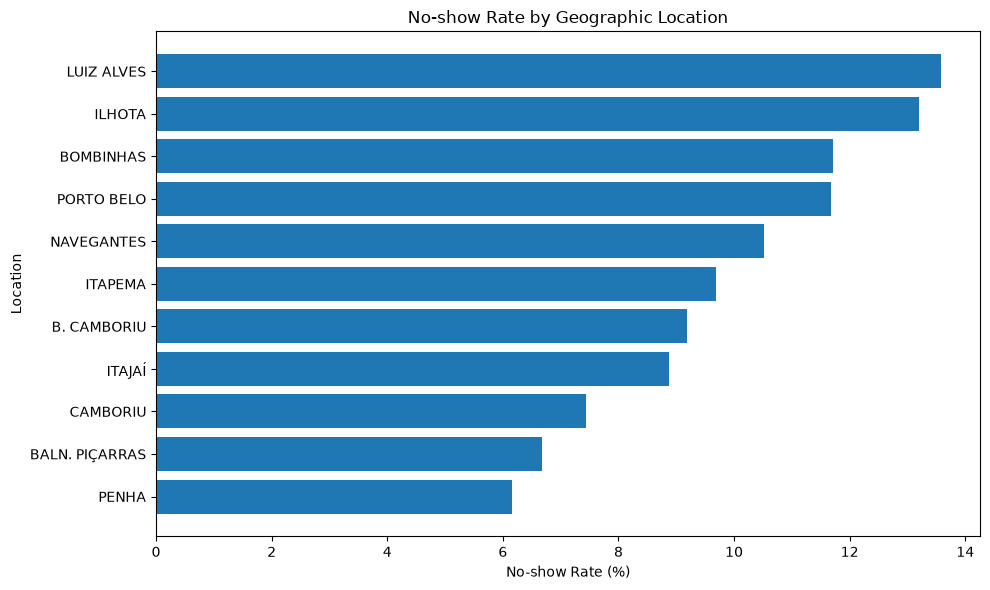

In [6]:
# Plot no-show rate by location

place_rate_plot = place_analysis.sort_values(
    'no_show_rate_pct',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    place_rate_plot['place'],
    place_rate_plot['no_show_rate_pct']
)

plt.xlabel('No-show Rate (%)')
plt.ylabel('Location')
plt.title('No-show Rate by Geographic Location')

plt.tight_layout()
plt.show()

In [8]:
# Calculate each location's share of total appointments

place_analysis['appointment_share_pct'] = (
    place_analysis['total_appointments']
    / len(df_geo) * 100
)

place_analysis = place_analysis.sort_values(
    'total_appointments',
    ascending=False
)

print("Geographic demand summary:")
print(
    place_analysis[
        [
            'place',
            'total_appointments',
            'appointment_share_pct',
            'no_shows',
            'no_show_rate_pct'
        ]
    ].round(2).to_string(index=False)
)

Geographic demand summary:
         place  total_appointments  appointment_share_pct  no_shows  no_show_rate_pct
        ITAJAÍ               20512                  18.72      1821              8.88
   B. CAMBORIU                6018                   5.49       553              9.19
      CAMBORIU                5523                   5.04       411              7.44
    NAVEGANTES                3901                   3.56       410             10.51
       ITAPEMA                2665                   2.43       258              9.68
     BOMBINHAS                1707                   1.56       200             11.72
         PENHA                1038                   0.95        64              6.17
    PORTO BELO                 950                   0.87       111             11.68
BALN. PIÇARRAS                 943                   0.86        63              6.68
        ILHOTA                 583                   0.53        77             13.21
    LUIZ ALVES             

In [9]:
# Calculate the share of total appointments from the top 3 locations

top_3_places = place_analysis.head(3)

top_3_appointments = top_3_places['total_appointments'].sum()

top_3_appointment_share = (
    top_3_appointments / len(df_geo) * 100
)

print("Top 3 locations by appointment volume:")
print(
    top_3_places[
        ['place', 'total_appointments']
    ].to_string(index=False)
)

print("\nTop 3 appointments:", top_3_appointments)
print(
    "Share of all appointments:",
    round(top_3_appointment_share, 2),
    "%"
)

Top 3 locations by appointment volume:
      place  total_appointments
     ITAJAÍ               20512
B. CAMBORIU                6018
   CAMBORIU                5523

Top 3 appointments: 32053
Share of all appointments: 29.26 %


In [10]:
# Classify locations based on appointment demand

geo_priority = place_analysis.copy()

geo_priority['resource_priority'] = pd.cut(
    geo_priority['total_appointments'],
    bins=[-1, 1000, 5000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

geo_priority = geo_priority.sort_values(
    'total_appointments',
    ascending=False
)

print("Geographic resource-planning priority:")
print(
    geo_priority[
        [
            'place',
            'total_appointments',
            'appointment_share_pct',
            'no_shows',
            'no_show_rate_pct',
            'resource_priority'
        ]
    ].round(2).to_string(index=False)
)


Geographic resource-planning priority:
         place  total_appointments  appointment_share_pct  no_shows  no_show_rate_pct resource_priority
        ITAJAÍ               20512                  18.72      1821              8.88              High
   B. CAMBORIU                6018                   5.49       553              9.19              High
      CAMBORIU                5523                   5.04       411              7.44              High
    NAVEGANTES                3901                   3.56       410             10.51            Medium
       ITAPEMA                2665                   2.43       258              9.68            Medium
     BOMBINHAS                1707                   1.56       200             11.72            Medium
         PENHA                1038                   0.95        64              6.17            Medium
    PORTO BELO                 950                   0.87       111             11.68               Low
BALN. PIÇARRAS           

In [11]:
# Calculate appointment concentration in high-priority locations

high_priority_geo = geo_priority[
    geo_priority['resource_priority'] == 'High'
]

high_priority_appointments = high_priority_geo[
    'total_appointments'
].sum()

meaningful_location_appointments = place_analysis[
    'total_appointments'
].sum()

high_priority_share = (
    high_priority_appointments
    / meaningful_location_appointments
    * 100
)

print("High-priority locations:")
print(
    high_priority_geo[
        ['place', 'total_appointments']
    ].to_string(index=False)
)

print("\nAppointments in high-priority locations:",
      high_priority_appointments)

print(
    "Share of appointments among locations with >=100 appointments:",
    round(high_priority_share, 2),
    "%"
)

High-priority locations:
      place  total_appointments
     ITAJAÍ               20512
B. CAMBORIU                6018
   CAMBORIU                5523

Appointments in high-priority locations: 32053
Share of appointments among locations with >=100 appointments: 72.25 %


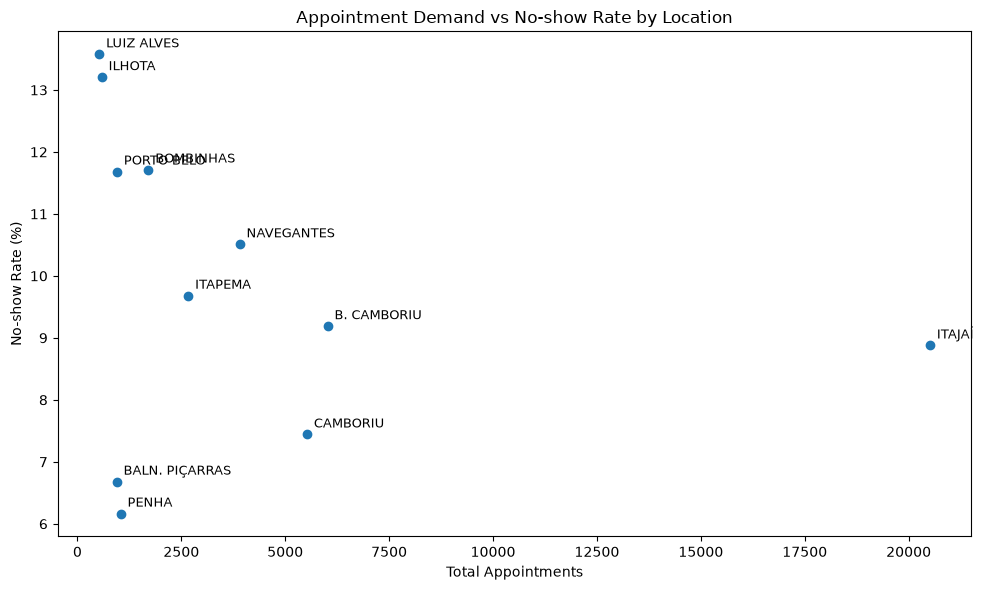

In [12]:
# Compare appointment demand with no-show rate

plt.figure(figsize=(10, 6))

plt.scatter(
    place_analysis['total_appointments'],
    place_analysis['no_show_rate_pct']
)

# Add location labels
for _, row in place_analysis.iterrows():
    plt.annotate(
        row['place'],
        (row['total_appointments'], row['no_show_rate_pct']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Total Appointments')
plt.ylabel('No-show Rate (%)')
plt.title('Appointment Demand vs No-show Rate by Location')

plt.tight_layout()
plt.show()

## Business Insight — Geographic Resource Planning

The geographic analysis shows that appointment demand is concentrated in a small number of locations.

### Key Findings

- **ITAJAÍ** has the highest appointment volume with **20,512 appointments**, representing **18.72%** of all appointments.
- **B. CAMBORIU** has **6,018 appointments**, while **CAMBORIU** has **5,523 appointments**.
- The three highest-volume locations together account for **32,053 appointments**, or **29.26% of all appointments**.
- These three locations represent **72.25% of appointment volume among the 11 locations with at least 100 appointments**.
- Among the analyzed high-volume locations, no-show rates range from **6.17% to 13.58%**.
- **LUIZ ALVES (13.58%)** and **ILHOTA (13.21%)** have relatively higher no-show rates, although their appointment volumes are much smaller.
- **ITAJAÍ** has the largest demand volume, while its no-show rate is **8.88%**.

### Resource-Planning Approach

- Prioritize capacity planning for locations with consistently high appointment volumes.
- Consider specialist and equipment allocation based on historical demand concentration.
- Monitor locations with comparatively higher no-show rates to identify opportunities for targeted patient engagement.
- Use both appointment volume and no-show rate rather than relying on either metric alone.

### Business Value

Geographic demand analysis can help healthcare management understand where appointment capacity is most heavily utilized and support more informed allocation of specialists and equipment.

> The `place` field contains a very large number of unique values and appears to contain a mixture of geographic names and synthetic-looking values. Therefore, this analysis treats `place` as a location field rather than assuming every unique value represents a distinct city. Locations with at least 100 appointments were used for the main comparison to reduce the influence of extremely low-volume locations.

> **Data-quality note:** `B. CAMBORIU` and `CAMBORIU` may represent related geographic areas, but they were kept as separate categories because the dataset does not provide a verified mapping between the labels.

## Geographic Resource-Planning Summary

| Location | Appointments | Appointment Share (%) | No-Shows | No-Show Rate (%) | Resource Priority |
|---|---:|---:|---:|---:|---|
| ITAJAÍ | 20,512 | 18.72 | 1,821 | 8.88 | High |
| B. CAMBORIU | 6,018 | 5.49 | 553 | 9.19 | High |
| CAMBORIU | 5,523 | 5.04 | 411 | 7.44 | High |
| NAVEGANTES | 3,901 | 3.56 | 410 | 10.51 | Medium |
| ITAPEMA | 2,665 | 2.43 | 258 | 9.68 | Medium |
| BOMBINHAS | 1,707 | 1.56 | 200 | 11.72 | Medium |
| PENHA | 1,038 | 0.95 | 64 | 6.17 | Medium |
| PORTO BELO | 950 | 0.87 | 111 | 11.68 | Low |
| BALN. PIÇARRAS | 943 | 0.86 | 63 | 6.68 | Low |
| ILHOTA | 583 | 0.53 | 77 | 13.21 | Low |
| LUIZ ALVES | 523 | 0.48 | 71 | 13.58 | Low |